In [1]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Generating sample data
np.random.seed(42)
X = 0.3 * np.random.randn(100, 2)
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.r_[X + 2, X - 2, X_outliers]

In [3]:
print(X)

[[ 2.14901425  1.95852071]
 [ 2.19430656  2.45690896]
 [ 1.92975399  1.92975891]
 [ 2.47376384  2.23023042]
 [ 1.85915768  2.16276801]
 [ 1.86097469  1.86028107]
 [ 2.07258868  1.42601593]
 [ 1.48252465  1.83131374]
 [ 1.69615066  2.0942742 ]
 [ 1.72759278  1.57630889]
 [ 2.43969463  1.93226711]
 [ 2.02025846  1.57257554]
 [ 1.83668518  2.03327678]
 [ 1.65470193  2.11270941]
 [ 1.81980839  1.91249188]
 [ 1.81948802  2.55568346]
 [ 1.99595083  1.68268672]
 [ 2.24676347  1.63374691]
 [ 2.06265908  1.41209896]
 [ 1.60154419  2.05905837]
 [ 2.22153997  2.05141048]
 [ 1.96530552  1.90966889]
 [ 1.5564434   1.78404674]
 [ 1.86180837  2.31713667]
 [ 2.10308549  1.47108795]
 [ 2.09722519  1.88447532]
 [ 1.7969234   2.18350289]
 [ 2.30929986  2.27938404]
 [ 1.74823474  1.90723629]
 [ 2.09937903  2.29266354]
 [ 1.85624773  1.94430231]
 [ 1.66809951  1.64113801]
 [ 2.24375775  2.40687201]
 [ 1.97839696  2.30105987]
 [ 2.10849081  1.80646407]
 [ 2.10841868  2.46141097]
 [ 1.98925219  2.4693931 ]
 

In [4]:
# Fit the nearest neighbors model
k = 10  # Number of neighbors
knn = NearestNeighbors(n_neighbors=k)
knn.fit(X)

NearestNeighbors(n_neighbors=10)

In [6]:
# Calculate distances to k-th nearest neighbors for each point
distances, _ = knn.kneighbors(X)
kth_distance = distances[:, -1]
# Set threshold for outlier detection
threshold = np.percentile(kth_distance, 95)  # Adjust the percentile based on your data
# Detect outliers
outlier_indices = np.where(kth_distance > threshold)[0]
outliers = X[outlier_indices]


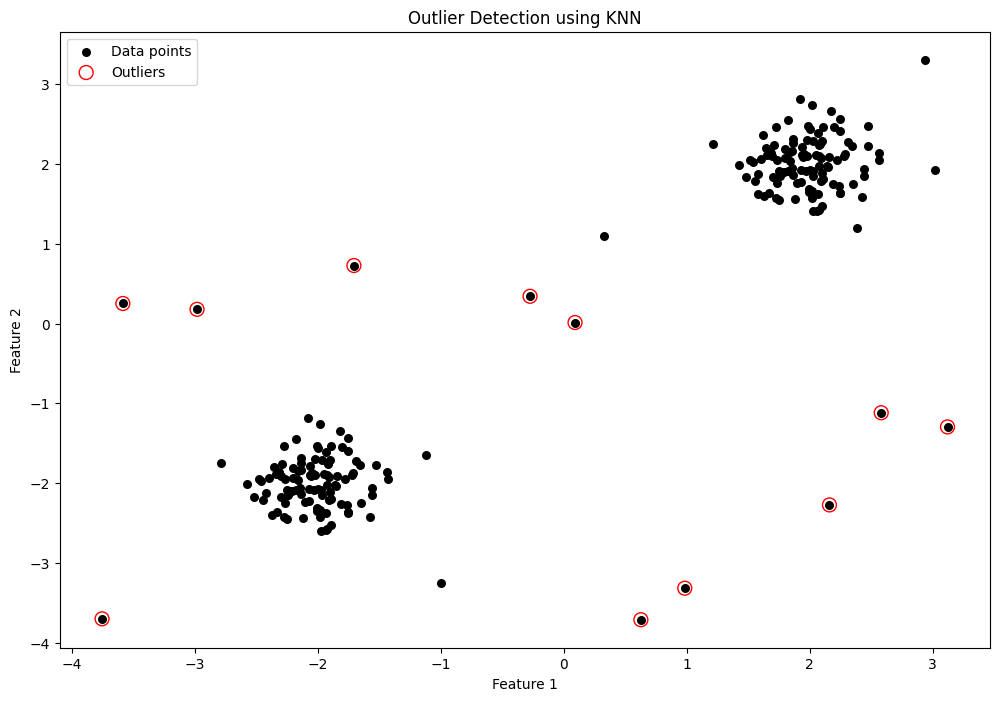

In [7]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], color='k', s=30, label="Data points")
plt.scatter(outliers[:, 0], outliers[:, 1], marker='o',
            edgecolors='r', facecolors='none', s=100, label="Outliers")
plt.title('Outlier Detection using KNN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [9]:
import pandas as pd
df_customer = pd.read_csv('customer.csv')
display(df_customer.head())
display(df_customer.info())

,CustomerID,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerID      22 non-null     int64
 1   Age             22 non-null     int64
 2   Annual_Income   22 non-null     int64
 3   Spending_Score  22 non-null     int64
dtypes: int64(4)
memory usage: 836.0 bytes


None

In [10]:
# Detect outliers
outlier_indices_customer = np.where(kth_distance_customer > threshold_customer)[0]
outliers_customer = X_customer.iloc[outlier_indices_customer]
display(outliers_customer)

NameError: name 'kth_distance_customer' is not defined

In [16]:
from sklearn.preprocessing import StandardScaler

# Select the relevant features for outlier detection
X_customer = df_customer[['Annual_Income', 'Spending_Score']]

# Scale the data using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_customer)

# Fit the nearest neighbors model to the scaled data
k_customer = 5  # You can adjust this value, typically between 2 and 50
knn_customer = NearestNeighbors(n_neighbors=k_customer)
knn_customer.fit(X_scaled)

# Calculate distances to k-th nearest neighbors for each point
distances_customer, _ = knn_customer.kneighbors(X_scaled)
kth_distance_customer = distances_customer[:, -1]

# Set threshold for outlier detection (e.g., 90th percentile)
threshold_customer = np.percentile(kth_distance_customer, 90) # Adjust this percentile as needed

# Detect outliers
outlier_indices_customer = np.where(kth_distance_customer > threshold_customer)[0]
outliers_customer = X_customer.iloc[outlier_indices_customer]


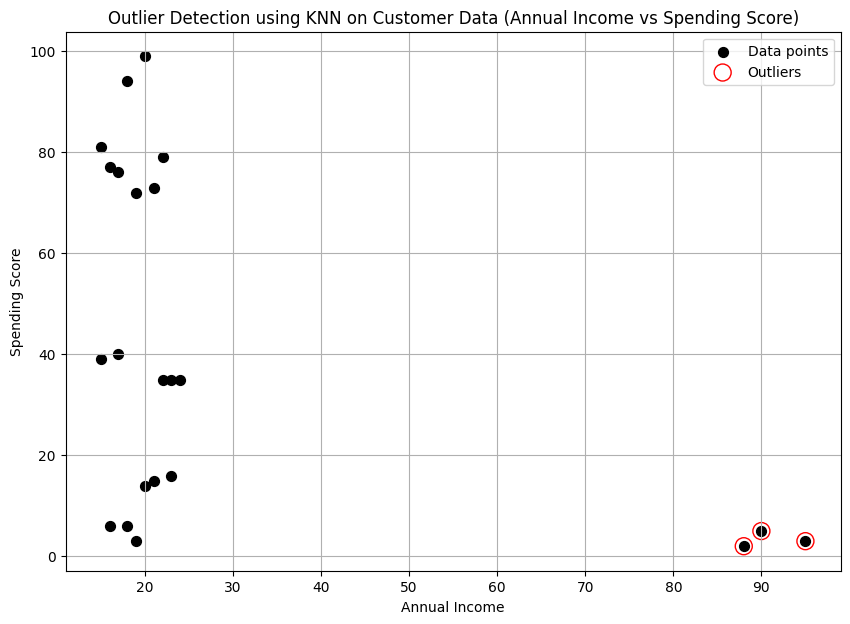

In [17]:
# Plot the results
plt.figure(figsize=(10, 7))
plt.scatter(X_customer['Annual_Income'], X_customer['Spending_Score'], color='k', s=50, label='Data points')
plt.scatter(outliers_customer['Annual_Income'], outliers_customer['Spending_Score'],
            marker='o', edgecolors='r', facecolors='none', s=150, label='Outliers')
plt.title('Outlier Detection using KNN on Customer Data (Annual Income vs Spending Score)')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.grid(True)
plt.show()